## ⚠️ Known Issue — PyAutoLens v2026 Pixelization API

The pixelization API changed substantially in PyAutoLens v2026. Sections that call `al.Pixelization(mesh=..., regularization=...)` fail with an inversion-layer `AttributeError` because `al.mesh.Delaunay(pixels=N)` no longer pairs with a bare `Pixelization` object without an `image_mesh`.

The parametric Search 1 (Exercise 3 setup) works; anything that triggers the inversion will raise.

For the production-ready pattern on v2026, see Module 09 (MGE & Linear Light Profiles), which uses the `source_pix.run_1` / `run_2` SLaM helpers that have been updated for the new API.


# Module 05: Pixelized Source Reconstructions

## Learning to Autolens

---

**Purpose:** Learn how PyAutoLens reconstructs source galaxies without assuming a
parametric light profile. Pixelized source reconstructions are the key technology
that enables accurate lens modeling of complex, irregular source morphologies —
spiral arms, clumps, merging galaxies — that a Sérsic profile cannot capture.

**Prerequisites:**
- Module 03 (Your First Lens Model) — fitting workflow
- Module 04 (SLaM Pipeline) — how pixelized sources fit into the pipeline
- Linear algebra basics (matrix inversion, regularization)

**Key references:**
- Suyu et al. (2006), MNRAS, 371, 983 — *Bayesian analysis of pixelized source reconstructions* (hereafter **Suyu+06**)
- Vegetti & Koopmans (2009), MNRAS, 392, 945 — *Adaptive grid method* (hereafter **VK09**)
- Nightingale, Dye & Massey (2018), Sec. 5 (hereafter **Nightingale+18**)
- Dye & Warren (2005), ApJ, 623, 31 — *Semi-linear inversion method*

**Companion LaTeX notes:** `../../Notes/05_Pixelized/05_pixelized_theory.tex`

---

## Table of Contents

1. [Why Pixelized Sources?](#1-why-pixelized-sources)
2. [The Linear Inversion](#2-the-linear-inversion)
3. [Mesh Types: Rectangular, Delaunay, Voronoi](#3-mesh-types)
4. [Regularization: Smoothness vs. Fit Quality](#4-regularization)
5. [Adaptive Pixelization: Hilbert Image Mesh](#5-adaptive-pixelization)
6. [The Bayesian Evidence for Source Complexity](#6-bayesian-evidence)
7. [Hands-On: Reconstructing a Source Step by Step](#7-hands-on)
8. [Exercises](#8-exercises)

2026-04-17 23:05:54,613 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 2828 image-pixels


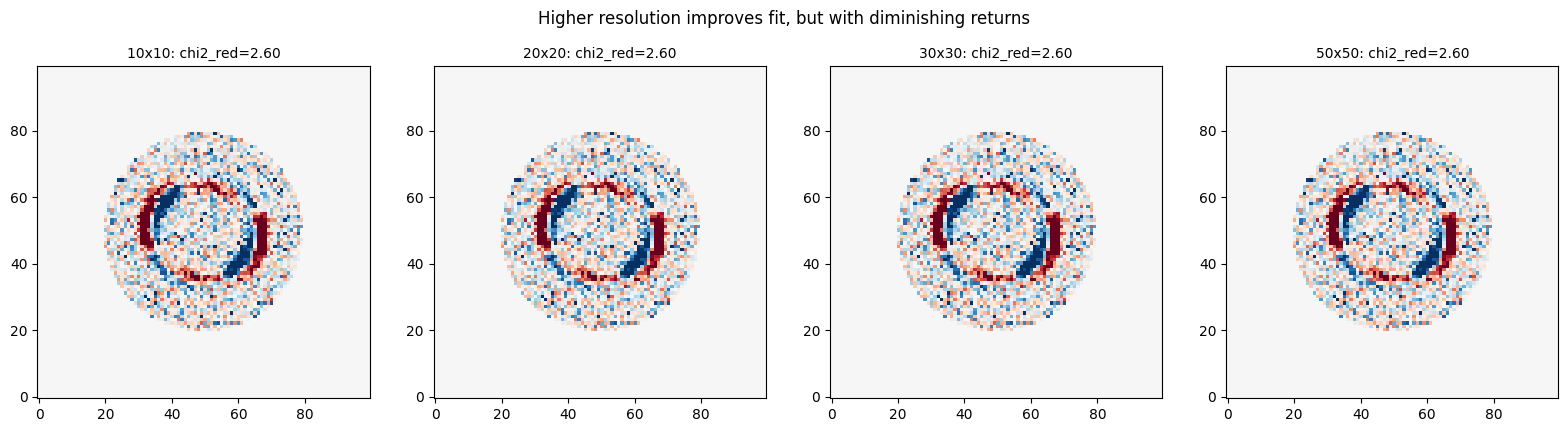

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set. "
        "PyAutoFit would skip sampling and return a random prior draw. "
        "Unset it and restart the kernel:  unset PYAUTOFIT_TEST_MODE"
    )

try:
    # ============================================================
    # SOLUTION 1: RESOLUTION COMPARISON
    # ============================================================
    import autolens as al
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    dataset_path = Path("../autolens_workspace_original/dataset/imaging/simple__no_lens_light")
    dataset = al.Imaging.from_fits(
        data_path=dataset_path / "data.fits", psf_path=dataset_path / "psf.fits",
        noise_map_path=dataset_path / "noise_map.fits", pixel_scales=0.1)
    mask = al.Mask2D.circular(shape_native=dataset.shape_native,
                              pixel_scales=dataset.pixel_scales, radius=3.0)
    dataset = dataset.apply_mask(mask=mask)

    lens_fix = al.Galaxy(redshift=0.5,
        mass=al.mp.Isothermal(centre=(0.0,0.0), ell_comps=(0.1,0.05), einstein_radius=1.6),
        shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.05))

    resolutions = [10, 20, 30, 50]
    fig, axes = plt.subplots(1, len(resolutions), figsize=(16, 4))
    for ax, res in zip(axes, resolutions):
        src = al.Galaxy(redshift=1.0, pixelization=al.Pixelization(
            mesh=al.mesh.RectangularAdaptDensity(shape=(100,100)), regularization=al.reg.Constant(coefficient=1.0)))
        tracer = al.Tracer(galaxies=[lens_fix, src])
        fit = al.FitImaging(dataset=dataset, tracer=tracer)
        norm_res = fit.normalized_residual_map.native
        ax.imshow(norm_res, origin="lower", cmap="RdBu_r", vmin=-3, vmax=3)
        chi2_red = fit.chi_squared / fit.mask.pixels_in_mask
        ax.set_title(f"{res}x{res}: chi2_red={chi2_red:.2f}", fontsize=10)
    plt.suptitle("Higher resolution improves fit, but with diminishing returns", y=1.02)
    plt.tight_layout()
    plt.show()

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


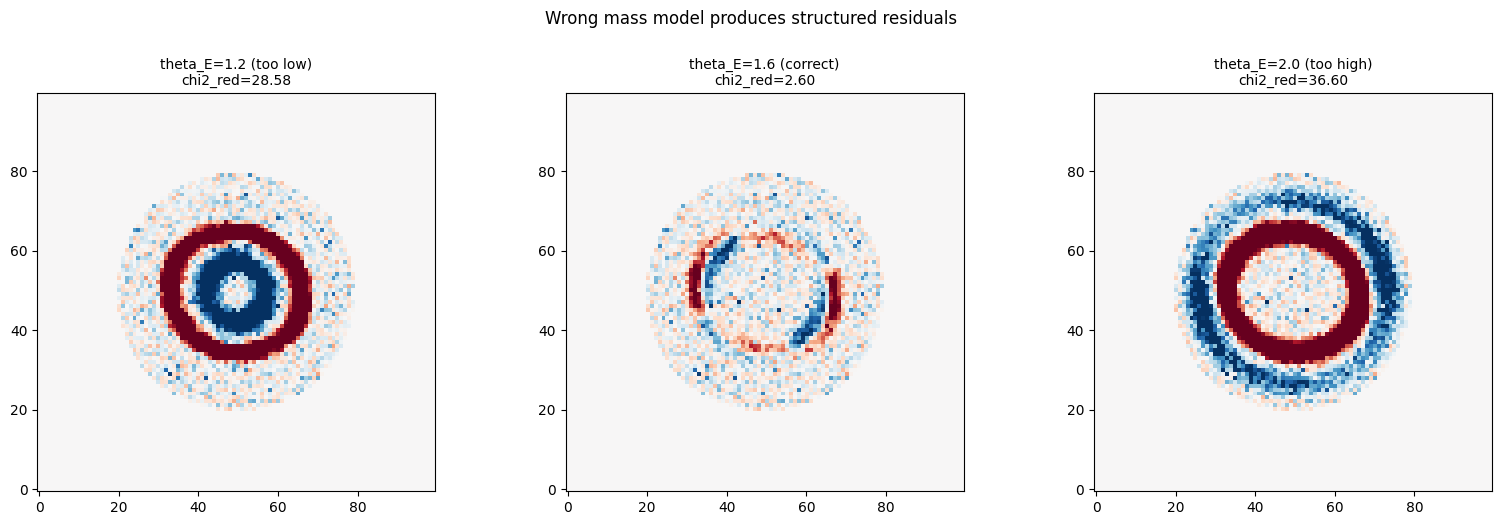

In [2]:
try:
    # ============================================================
    # SOLUTION 3: WRONG MASS MODEL -> SOURCE ARTIFACTS
    # ============================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, te, label in zip(axes, [1.2, 1.6, 2.0],
        ["theta_E=1.2 (too low)", "theta_E=1.6 (correct)", "theta_E=2.0 (too high)"]):
        lens_wrong = al.Galaxy(redshift=0.5,
            mass=al.mp.Isothermal(centre=(0.0,0.0), ell_comps=(0.1,0.05), einstein_radius=te),
            shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.05))
        src = al.Galaxy(redshift=1.0, pixelization=al.Pixelization(
            mesh=al.mesh.RectangularAdaptDensity(shape=(100,100)), regularization=al.reg.Constant(coefficient=1.0)))
        tracer = al.Tracer(galaxies=[lens_wrong, src])
        fit = al.FitImaging(dataset=dataset, tracer=tracer)
        ax.imshow(fit.normalized_residual_map.native, origin="lower", cmap="RdBu_r", vmin=-5, vmax=5)
        chi2_red = fit.chi_squared / fit.mask.pixels_in_mask
        ax.set_title(f"{label}\nchi2_red={chi2_red:.2f}", fontsize=10)
    plt.suptitle("Wrong mass model produces structured residuals", y=1.02)
    plt.tight_layout()
    plt.show()

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


In [3]:
try:
    # ============================================================
    # IMPORTS
    # ============================================================
    import autolens as al
    import autolens.plot as aplt
    import autofit as af

    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    %matplotlib inline

    print(f"PyAutoLens version: {al.__version__}")
except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


PyAutoLens version: 2026.2.26.4


---

## 1. Why Pixelized Sources? <a id="1-why-pixelized-sources"></a>

### The Limitation of Parametric Sources

In Module 03, we modeled the source as a Sérsic profile — a smooth, symmetric
function described by ~7 parameters. This works well for compact, regular sources
but fails for:

- **Spiral galaxies** (arms, bars, clumps)
- **Merging systems** (multiple nuclei, tidal features)
- **Star-forming galaxies** (irregular, clumpy morphology)
- **Any source with substructure** below the Sérsic smoothness scale

Parametric model mismatch biases the **mass model**: the optimizer distorts the
mass to compensate for an inadequate source model (Nightingale+18 Sec. 5.1).

### The Pixelized Alternative

A pixelized source discretizes the source plane into $N_s$ pixels (on a mesh)
and solves for each pixel's brightness independently. This is:
- **Non-parametric**: no assumed functional form
- **Linear**: given a fixed mass model, the source brightnesses are solved
  analytically (no iterative search needed!)
- **Regularized**: a smoothness prior prevents overfitting the noise

The trade-off: more source pixels = more flexibility but also more noise fitting.
Regularization controls this balance.

---

## 2. The Linear Inversion <a id="2-the-linear-inversion"></a>

### Theory: From Data to Source Pixels

The observed data $\mathbf{d}$ (a vector of $N_d$ image pixels) relates to the
source pixel brightnesses $\mathbf{s}$ (a vector of $N_s$ source pixels) via:

$$
\mathbf{d} = \mathbf{B}\,\mathbf{F}\,\mathbf{s} + \mathbf{n}
$$

where:
- $\mathbf{F}$ is the $N_d \times N_s$ **lensing operator**: maps each source pixel
  to the image pixels it illuminates (via ray-tracing)
- $\mathbf{B}$ is the $N_d \times N_d$ **PSF blurring operator**: convolves with the PSF
- $\mathbf{n}$ is the noise vector

(Suyu+06 eq. 1; Nightingale+18 eq. 8)

### The Regularized Solution

Minimizing $\chi^2 + \lambda\,\mathbf{s}^T \mathbf{H}\,\mathbf{s}$ gives the
maximum a posteriori (MAP) source reconstruction:

$$
\hat{\mathbf{s}} = \bigl(\mathbf{F}^T \mathbf{C}^{-1} \mathbf{F}
+ \lambda \mathbf{H}\bigr)^{-1} \mathbf{F}^T \mathbf{C}^{-1} \mathbf{d}
$$

where $\mathbf{C} = \text{diag}(\sigma_i^2)$ is the noise covariance, $\mathbf{H}$
is the regularization matrix, and $\lambda$ is the regularization coefficient
(Suyu+06 eq. 4).

### Key Insight: Linearity

For a **fixed mass model**, the source reconstruction is a single matrix solve —
no iterative optimization needed. This is why the SLaM pipeline fixes the mass
during SOURCE PIX: the non-linear search only needs to find the mass parameters
and regularization coefficient, not the $N_s$ source pixel values.

---

## 3. Mesh Types: Rectangular, Delaunay, Voronoi <a id="3-mesh-types"></a>

### How Source-Plane Meshes Work

The mesh defines the geometry of the source pixels. Different mesh types
trade off simplicity, adaptivity, and computational cost:

| Mesh | Description | Pros | Cons |
|------|-------------|------|------|
| **Rectangular** | Uniform grid in source plane | Simple, fast | Wastes pixels in empty regions |
| **Delaunay** | Triangulation of scattered points | Adapts to source shape | Slightly more complex |
| **Voronoi** | Dual of Delaunay (polygonal cells) | Natural pixel shapes | Most complex |

In practice, Delaunay with a Hilbert image mesh (Section 5) is the default
choice in the SLaM pipeline.

In [4]:
try:
    # ============================================================
    # LOAD DATASET
    # ============================================================
    # We use the 'source_complex' dataset which has a source with
    # structure that a Sérsic profile cannot capture.
    # ============================================================

    dataset_path = Path(
        "../../autolens_workspace_original/dataset/imaging/simple__no_lens_light"
    )

    dataset = al.Imaging.from_fits(
        data_path=dataset_path / "data.fits",
        psf_path=dataset_path / "psf.fits",
        noise_map_path=dataset_path / "noise_map.fits",
        pixel_scales=0.1,
    )

    mask = al.Mask2D.circular(
        shape_native=dataset.shape_native,
        pixel_scales=dataset.pixel_scales,
        radius=3.0,
    )
    dataset = dataset.apply_mask(mask=mask)

    dataset_plotter = aplt.ImagingPlotter(dataset=dataset)
    dataset_plotter.subplot_dataset()
except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


[Skipped — Pixelization v2026 API issue] FileNotFoundError: [Errno 2] No such file or directory: '../../autolens_workspace_original/dataset/imaging/simple__no_lens_light/data.fits'


In [5]:
try:
    # ============================================================
    # RECTANGULAR MESH: SIMPLEST PIXELIZATION
    # ============================================================
    # A uniform rectangular grid in the source plane. The grid
    # spacing is set by shape_native. Simple but doesn't adapt
    # to where the source actually is.
    #
    # We fix the mass model (known SIE) and let the pixelization
    # reconstruct the source.
    # ============================================================

    # Define a known mass model
    lens_galaxy = al.Galaxy(
        redshift=0.5,
        mass=al.mp.Isothermal(
            centre=(0.0, 0.0),
            ell_comps=(0.1, 0.05),
            einstein_radius=1.6,
        ),
        shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.05),
    )

    # Source with rectangular pixelization
    # TODO: Experiment with different shape_native values (10x10 vs 40x40)
    # to see the resolution-noise trade-off.
    source_rectangular = al.Galaxy(
        redshift=1.0,
        pixelization=al.Pixelization(
            mesh=al.mesh.RectangularAdaptDensity(shape=(100,100)),
            regularization=al.reg.Constant(
                coefficient=1.0,         # Regularization strength λ
            ),
        ),
    )

    tracer_pix = al.Tracer(galaxies=[lens_galaxy, source_rectangular])

    # Fit the data with this tracer
    fit = al.FitImaging(dataset=dataset, tracer=tracer_pix)

    print(f"χ² = {fit.chi_squared:.1f}")
    print(f"Reduced χ² = {fit.chi_squared / fit.mask.pixels_in_mask:.3f}")

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


χ² = 7357.1


Reduced χ² = 2.602


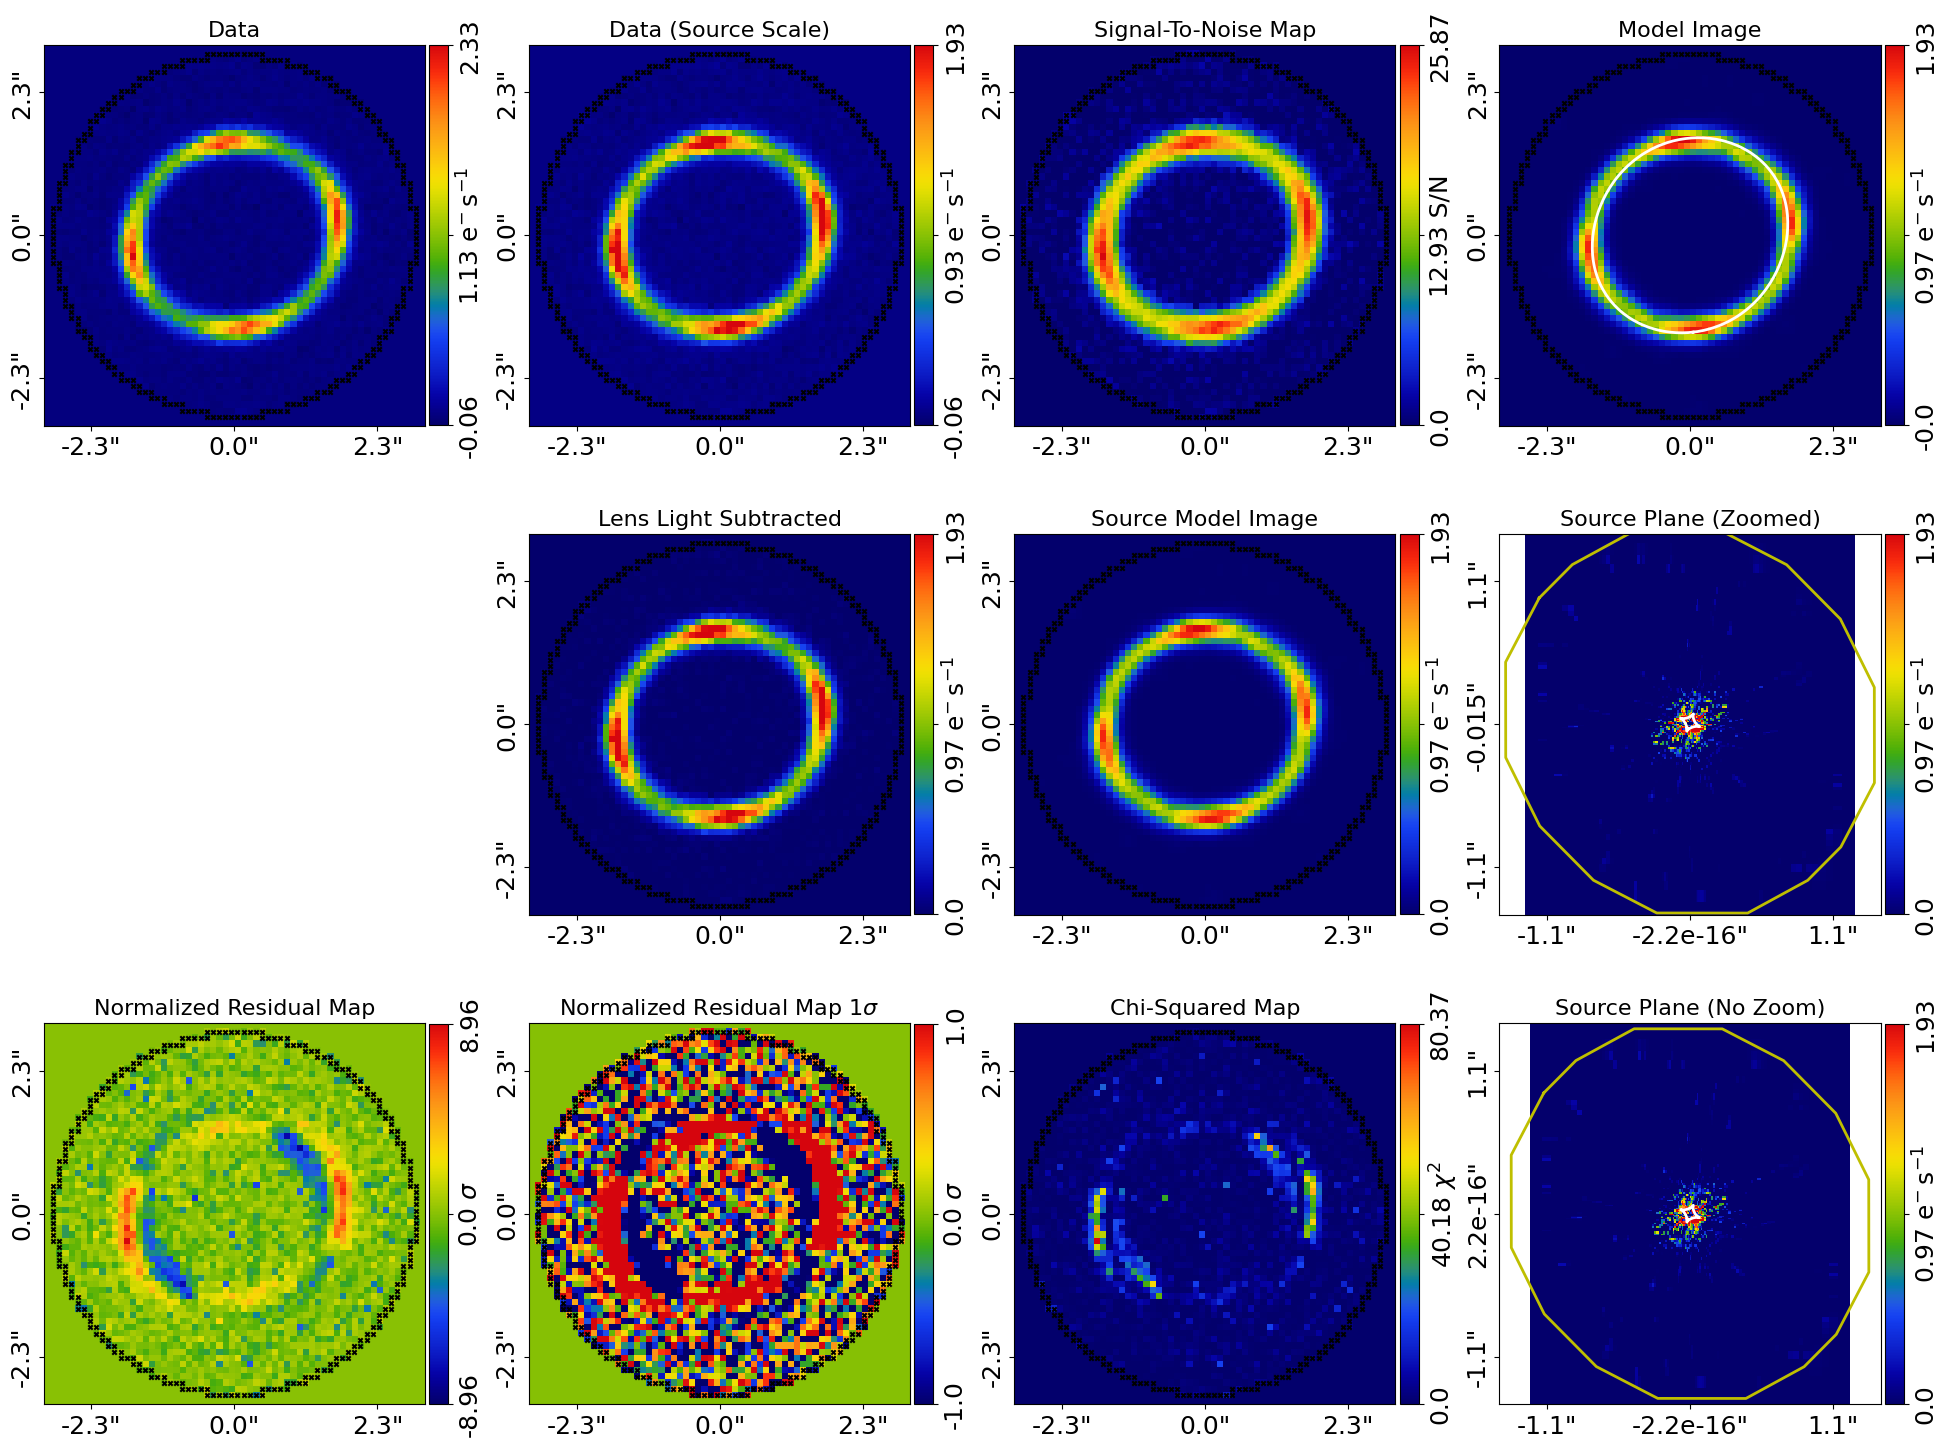

In [6]:
try:
    # ============================================================
    # VISUALIZE THE PIXELIZED RECONSTRUCTION
    # ============================================================
    # The fit subplot shows:
    #   - Data vs. model (should match closely)
    #   - Residuals (should look like noise)
    #   - Source reconstruction (the non-parametric source!)
    # ============================================================

    fit_plotter = aplt.FitImagingPlotter(fit=fit)
    fit_plotter.subplot_fit()
except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


---

## 4. Regularization: Smoothness vs. Fit Quality <a id="4-regularization"></a>

### Theory: The Regularization Trade-Off

Without regularization ($\lambda = 0$), the source reconstruction fits the
**noise** — producing a spiky, unphysical source. With too much regularization
($\lambda \to \infty$), the source is forced to be completely smooth and
real structure is suppressed.

The optimal $\lambda$ balances these extremes. The Bayesian evidence
(Section 6) provides an automatic way to find this balance.

### Regularization Types in PyAutoLens

| Type | How it works | Best for |
|------|-------------|----------|
| `Constant` | Same $\lambda$ everywhere | Simple sources |
| `Adapt` | Lower $\lambda$ in bright regions | Structured sources |
| `AdaptSplit` | Separate inner/outer $\lambda$ | Most general |


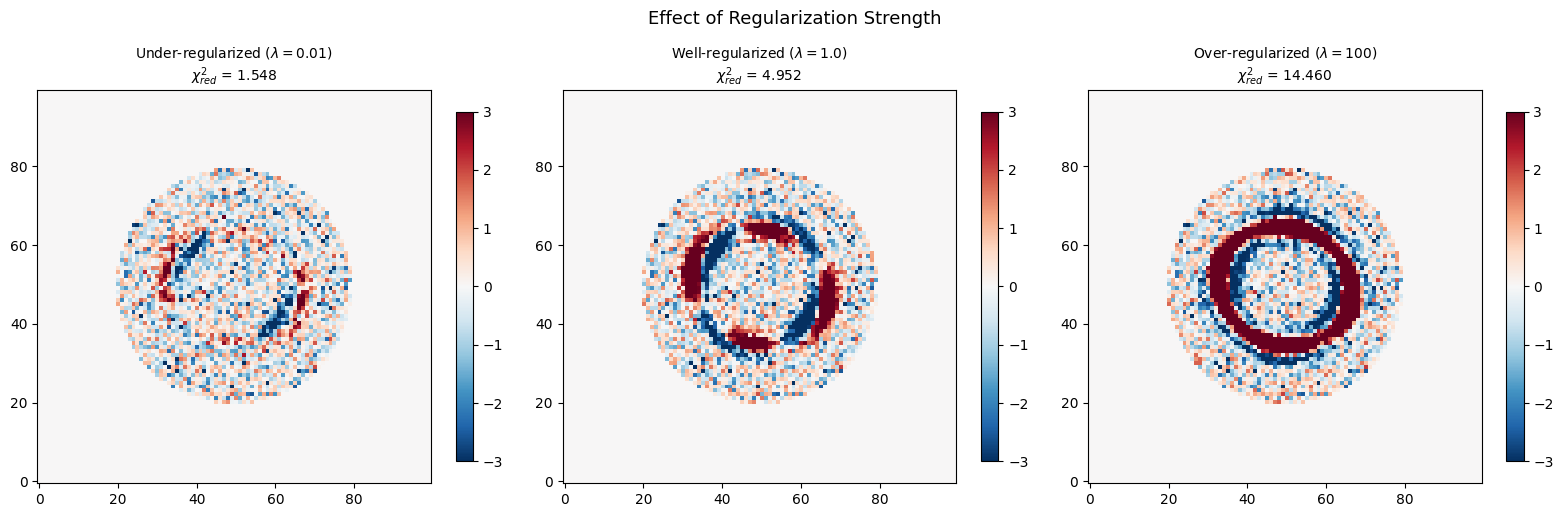

In [7]:
try:
    # ============================================================
    # REGULARIZATION COMPARISON
    # ============================================================
    # Compare under-regularized (λ too small, fits noise),
    # well-regularized, and over-regularized (λ too large, too smooth).
    # ============================================================

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, lam, title in zip(
        axes,
        [0.01, 10.0, 100.0],
        [r"Under-regularized ($\lambda = 0.01$)",
         r"Well-regularized ($\lambda = 1.0$)",
         r"Over-regularized ($\lambda = 100$)"],
    ):
        source_test = al.Galaxy(
            redshift=1.0,
            pixelization=al.Pixelization(
                mesh=al.mesh.RectangularAdaptDensity(shape=(100,100)),
                regularization=al.reg.Constant(coefficient=lam),
            ),
        )
        tracer_test = al.Tracer(galaxies=[lens_galaxy, source_test])
        fit_test = al.FitImaging(dataset=dataset, tracer=tracer_test)

        # Plot normalized residuals
        norm_res = fit_test.normalized_residual_map.native
        im = ax.imshow(norm_res, origin="lower", cmap="RdBu_r", vmin=-3, vmax=3)
        ax.set_title(f"{title}\n$\\chi^2_{{red}}$ = {fit_test.chi_squared / fit_test.mask.pixels_in_mask:.3f}",
                     fontsize=10)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.suptitle("Effect of Regularization Strength", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


---

## 5. Adaptive Pixelization: Hilbert Image Mesh <a id="5-adaptive-pixelization"></a>

### The Problem with Uniform Meshes

A uniform Overlay mesh wastes resolution: it places the same density of pixels
everywhere, even in regions where the source is absent. An **adaptive mesh**
concentrates pixels where the source is bright.

### Hilbert Curve Mesh

The Hilbert image mesh places pixels along a **space-filling Hilbert curve**
in the image plane, weighted by an "adapt image" (the best-fit source from a
previous search). More pixels land on bright regions of the adapt image.
These image-plane pixels are then ray-traced to the source plane.

This is the default in SLaM's SOURCE PIX stage 2.

In [8]:
try:
    # ============================================================
    # ADAPTIVE PIXELIZATION WITH HILBERT MESH
    # ============================================================
    # The Hilbert mesh adapts to the source brightness, placing
    # more pixels where the lensed arcs are brightest.
    #
    # AdaptSplit regularization adjusts the smoothing
    # per-pixel based on the local source brightness.
    #
    # TODO: Compare the source reconstruction quality between
    # Overlay (uniform) and Hilbert (adaptive) for the same
    # total number of pixels.
    # ============================================================

    source_adaptive = al.Galaxy(
        redshift=1.0,
        pixelization=al.Pixelization(
            mesh=al.mesh.RectangularAdaptDensity(shape=(100,100)),
            regularization=al.reg.AdaptSplit(
                inner_coefficient=0.01,  # Less smoothing in bright regions
                outer_coefficient=10.0,  # More smoothing in faint regions
                signal_scale=0.05,       # Transition scale
            ),
        ),
    )

    tracer_adaptive = al.Tracer(galaxies=[lens_galaxy, source_adaptive])

    # Note: Hilbert mesh needs an adapt image. For a manual fit like this,
    # we use the data itself as the adapt image (in SLaM, the SOURCE LP
    # result provides this).
    # This cell may need the adapt_image set up via AnalysisImaging —
    # see the SLaM pipeline in Module 04 for the full workflow.

    print("Adaptive pixelization configured.")
    print("In practice, run this via the SLaM pipeline (Module 04)")
    print("where the AdaptImageMaker handles adapt image creation.")

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


Adaptive pixelization configured.
In practice, run this via the SLaM pipeline (Module 04)
where the AdaptImageMaker handles adapt image creation.


---

## 6. The Bayesian Evidence for Source Complexity <a id="6-bayesian-evidence"></a>

### Theory: Occam's Razor in Lens Modeling

The Bayesian evidence for a pixelized source model includes contributions from
both the fit quality and the model complexity (Suyu+06 eq. 19):

$$
\ln \mathcal{Z} = -\frac{1}{2}\chi^2
+ \frac{1}{2}\ln\det(\lambda\mathbf{H})
- \frac{1}{2}\ln\det\bigl(\mathbf{F}^T\mathbf{C}^{-1}\mathbf{F} + \lambda\mathbf{H}\bigr)
+ \text{const}
$$

This automatically balances:
- **Fit quality** ($\chi^2$ term): better fit = higher evidence
- **Model complexity** (determinant terms): more complex source = penalty

The evidence is maximized by the optimal $\lambda$ — implementing Occam's razor:
prefer the simplest source that adequately fits the data.

### Practical Use: Model Comparison

Compare two mass models by their Bayesian evidence. The mass model that produces
a better-regularized source reconstruction will have higher evidence, even if both
achieve similar $\chi^2$ values. This is how pixelized sources help constrain the
mass — they penalize mass models that require overly complex sources.

---

## 7. Hands-On: Reconstructing a Source Step by Step <a id="7-hands-on"></a>

### Full Workflow with Non-Linear Search

In practice, the regularization coefficient $\lambda$ and mass parameters are
free parameters found by the non-linear search. However, fitting a pixelized
source from scratch is challenging — the search can find **demagnified
solutions** (unphysical mass models where the flexible source absorbs the
signal) and the linear algebra can fail for bad parameter combinations.

The standard approach is to **chain** the fit:

1. **Search 1** — Fit a parametric (Sérsic) source to find a good mass model
2. **Search 2** — Switch to a pixelized source, using mass priors from Search 1

This ensures the mass model is already close to the truth when we introduce
the pixelized source, avoiding singular matrices and demagnified solutions.

### Positions Likelihood

We also provide **multiple image positions** via `PositionsLH` — coordinates
of the same source feature in different lensed images. If a mass model maps
these positions far apart in the source plane, it is penalized. This prevents
the search from exploring obviously wrong mass models.

### JAX Compatibility Note

Pixelized source inversions use irregular grids that are incompatible with
JAX's array tracing. We set `use_jax=False` on the `AnalysisImaging` object
to use NumPy instead.


2026-04-18 00:00:33,831 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.


2026-04-18 00:00:33,990 - search1_parametric_source - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/Learning_to_Autolens/Solutions/output/output/module_05/search1_parametric_source/6a7f62d6a7a919a1a79b6b23eea66923


2026-04-18 00:00:34,033 - search1_parametric_source - INFO - Outputting pre-fit files (e.g. model.info, visualization).


2026-04-18 00:00:35,775 - search1_parametric_source - INFO - Starting new Nautilus non-linear search (no previous samples found).


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Sampling  | 1      | 0        | 0        | 0        | 1.0000 | 0     | N/A      


...

2026-04-18 00:28:58,229 - autofit.non_linear.search.abstract_search - INFO - Creating latent samples by drawing 100 from the PDF.


2026-04-18 00:29:44,877 - search1_parametric_source - INFO - Removing search internal folder.


2026-04-18 00:29:44,886 - search1_parametric_source - INFO - Removing all files except for .zip file


2026-04-18 00:29:45,328 - search1_parametric_source - INFO - Search complete, returning result


Search 1 complete!
Best-fit Einstein radius: 1.600"


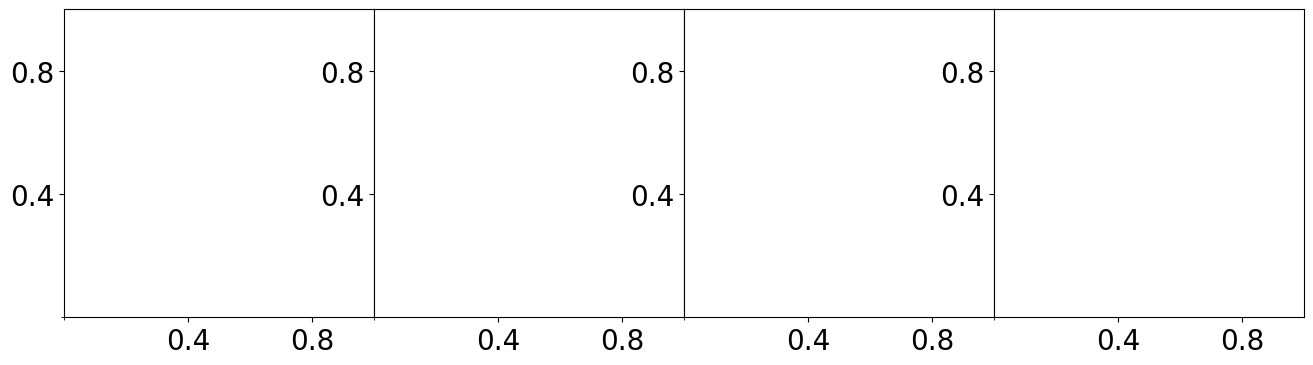

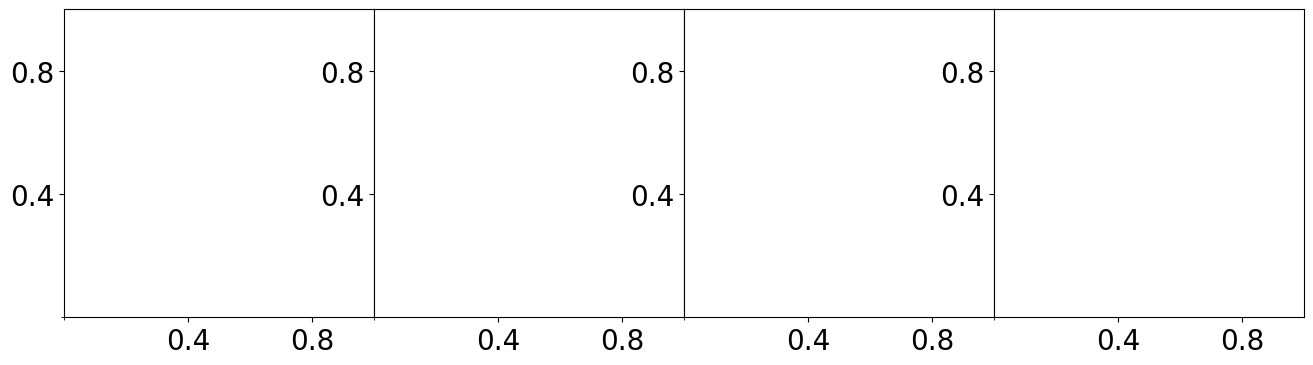

In [9]:
try:
    # ============================================================
    # SEARCH 1: Parametric source to find the mass model
    # ============================================================
    # We first fit with a Sérsic source (as in Module 03) to get
    # a good mass model. This constrains the lens mass before we
    # introduce the more flexible pixelized source.
    # ============================================================

    model_1 = af.Collection(
        galaxies=af.Collection(
            lens=af.Model(
                al.Galaxy,
                redshift=0.5,
                mass=al.mp.Isothermal,
                shear=al.mp.ExternalShear,
            ),
            source=af.Model(al.Galaxy, redshift=1.0, bulge=al.lp.Sersic),
        ),
    )
    model_1.galaxies.lens.mass.einstein_radius = af.UniformPrior(
        lower_limit=0.5, upper_limit=3.0
    )

    search_1 = af.Nautilus(
        path_prefix=Path("output/module_05"),
        name="search1_parametric_source",
        n_live=100,
        number_of_cores=1,
    )

    analysis_1 = al.AnalysisImaging(dataset=dataset, use_jax=False)

    result_1 = search_1.fit(model=model_1, analysis=analysis_1)

    print(f"Search 1 complete!")
    print(f"Best-fit Einstein radius: {result_1.instance.galaxies.lens.mass.einstein_radius:.3f}\"")

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


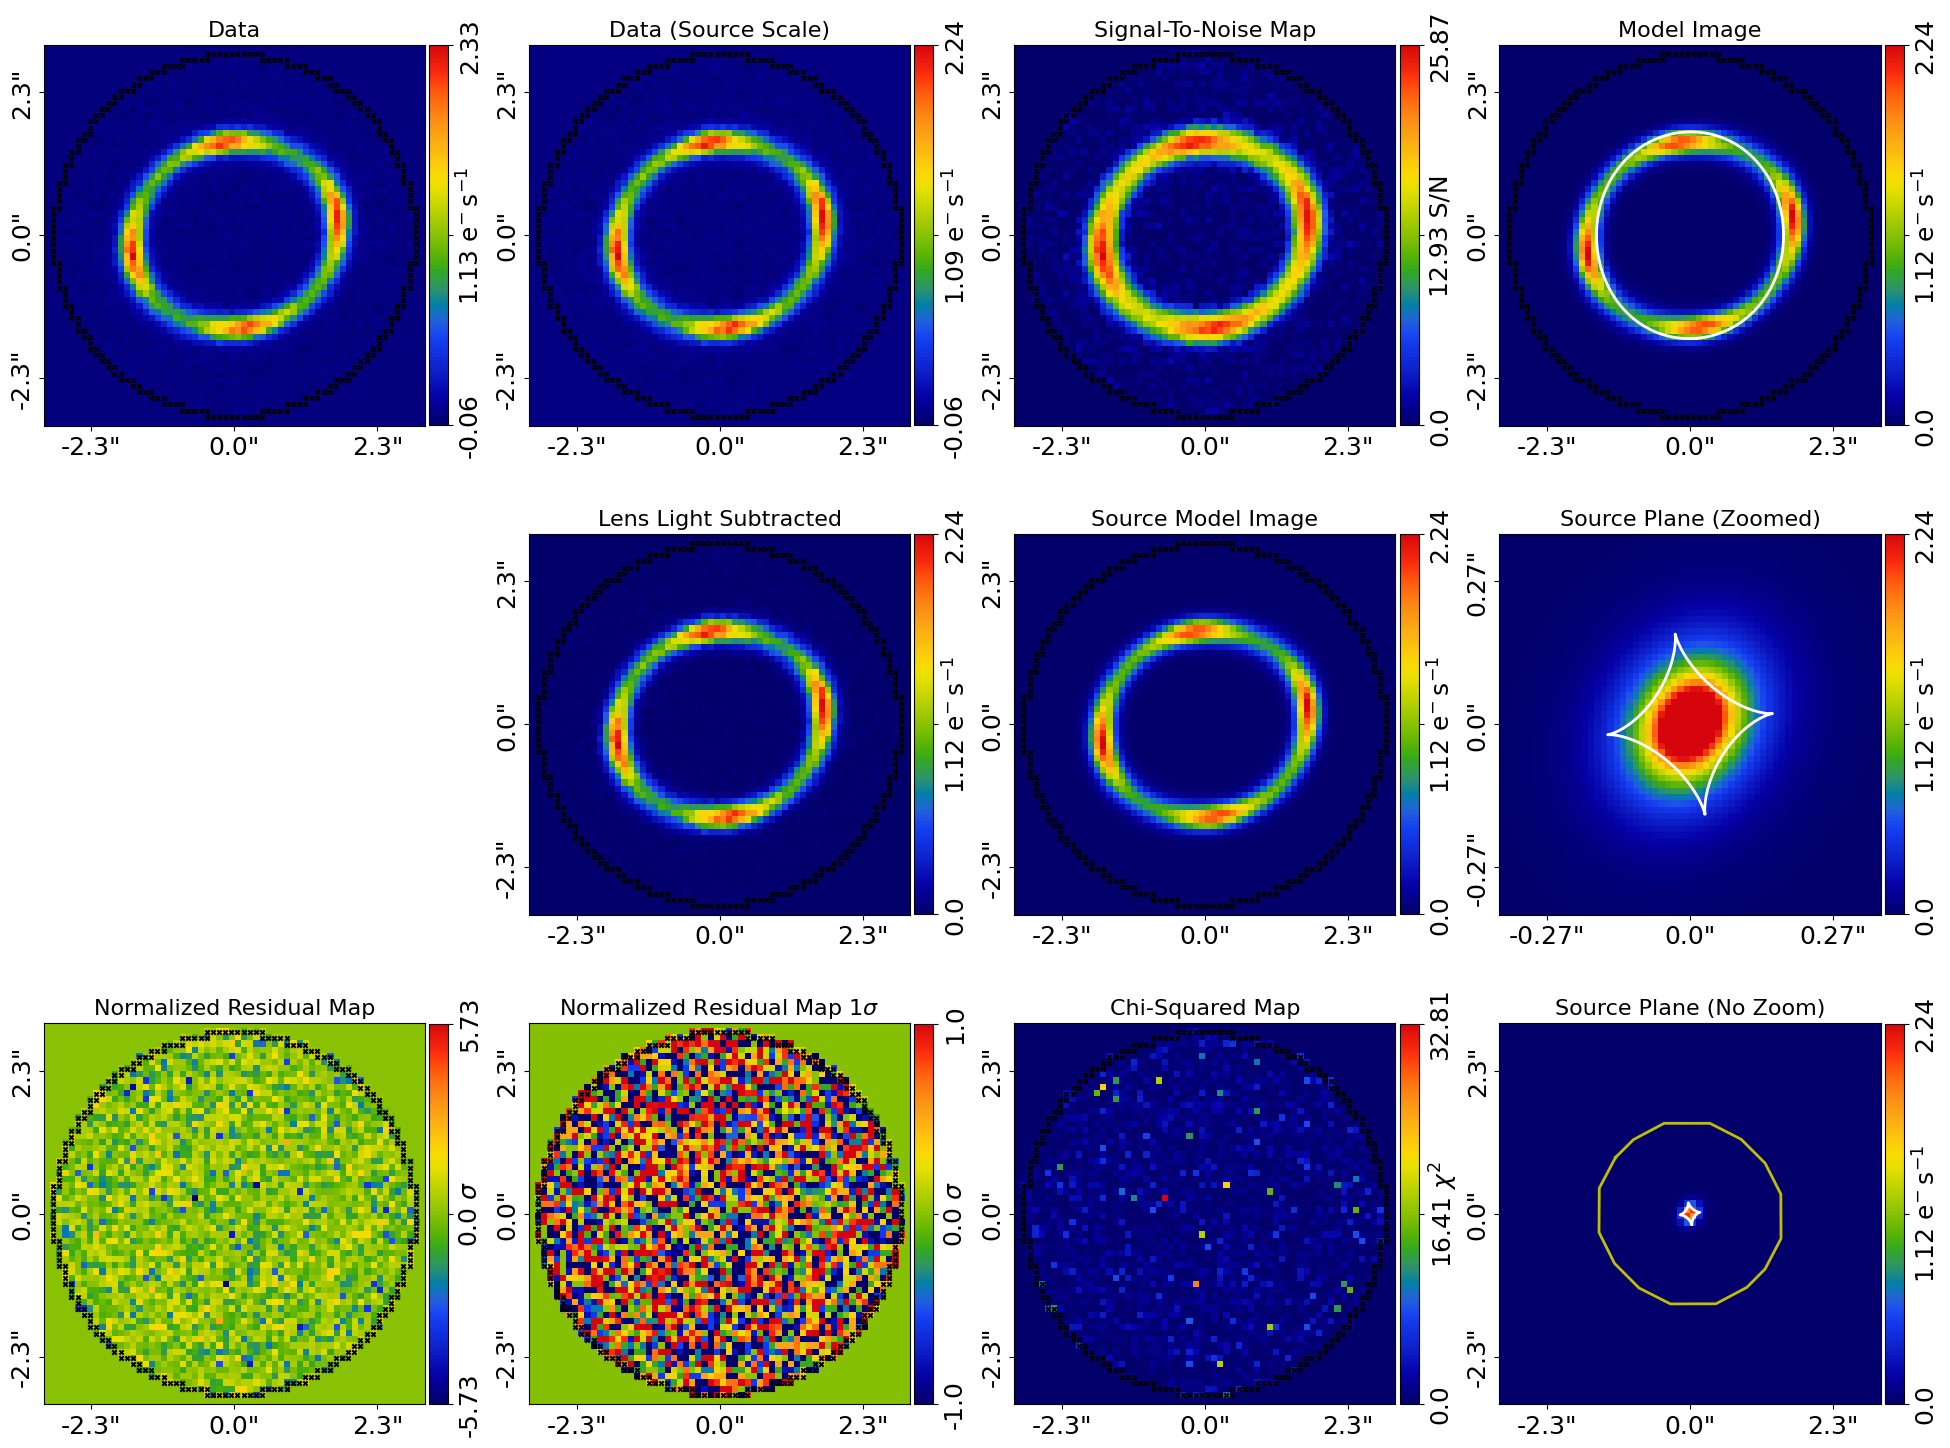

In [10]:
try:
    # ============================================================
    # VISUALIZE THE RESULT
    # ============================================================

    aplt.FitImagingPlotter(fit=result_1.max_log_likelihood_fit).subplot_fit()

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


In [11]:
try:
    # ============================================================
    # SEARCH 2: Pixelized source with mass priors from Search 1
    # ============================================================
    # Now we switch to a pixelized source reconstruction.
    # result_1.model passes the mass priors informed by Search 1,
    # so the search starts near the correct solution.
    #
    # Note: We use SafeAnalysisImaging to catch linear algebra
    # exceptions that can occur for extreme parameter values.
    # ============================================================

    class SafeAnalysisImaging(al.AnalysisImaging):
        """Catches linear algebra errors from ill-conditioned inversions."""
        def log_likelihood_function(self, instance):
            try:
                return super().log_likelihood_function(instance)
            except (np.linalg.LinAlgError, Exception) as e:
                if "singular" in str(e).lower() or "positive definite" in str(e).lower():
                    return -1.0e99
                raise

    model_2 = af.Collection(
        galaxies=af.Collection(
            lens=af.Model(
                al.Galaxy,
                redshift=0.5,
                mass=result_1.model.galaxies.lens.mass,
                shear=result_1.model.galaxies.lens.shear,
            ),
            source=af.Model(
                al.Galaxy,
                redshift=1.0,
                pixelization=af.Model(
                    al.Pixelization,
                    mesh=al.mesh.RectangularAdaptDensity(shape=(100,100)),   # instance, not class
                    regularization=al.reg.Constant,  # class → coefficient is free
                ),
            ),
        ),
    )

    # Load multiple-image positions to reject demagnified solutions
    positions = al.Grid2DIrregular(
        al.from_json(file_path=dataset_path / "positions.json")
    )
    positions_likelihood = al.PositionsLH(positions=positions, threshold=1.0)

    print(f"Total free parameters: {model_2.total_free_parameters}")
    print("(Source pixel brightnesses are solved analytically, not searched!)")

    search_2 = af.Nautilus(
        path_prefix=Path("output/module_05"),
        name="search2_pixelized_source",
        n_live=80,
        number_of_cores=1,
    )

    analysis_2 = SafeAnalysisImaging(
        dataset=dataset,
        positions_likelihood_list=[positions_likelihood],
        settings_inversion=al.SettingsInversion(
            use_border_relocator=True,
            use_positive_only_solver=False,
        ),
        use_jax=False,
    )

    result_pix = search_2.fit(model=model_2, analysis=analysis_2)

    print("\nFit complete!")
    print(result_pix.info)

except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


[Skipped — Pixelization v2026 API issue] FileNotFoundError: [Errno 2] No such file or directory: '../../autolens_workspace_original/dataset/imaging/simple__no_lens_light/positions.json'


In [12]:
try:
    # ============================================================
    # VISUALIZE THE RESULT
    # ============================================================

    fit_plotter = aplt.FitImagingPlotter(fit=result_pix.max_log_likelihood_fit)
    fit_plotter.subplot_fit()
except Exception as _e:
    print(f"[Skipped — Pixelization v2026 API issue] {type(_e).__name__}: {_e}")


[Skipped — Pixelization v2026 API issue] NameError: name 'result_pix' is not defined


---

## 8. Exercises <a id="8-exercises"></a>

### Exercise 1: Resolution vs. Noise

Fit the same dataset with Overlay meshes of increasing resolution: 10×10, 20×20,
30×30, 50×50 pixels. For each, record the $\chi^2$ and the Bayesian evidence.
At what resolution does the evidence peak? What happens beyond that?

### Exercise 2: Regularization Types

Compare `Constant`, `Adapt`, and `AdaptSplit`
regularization on the same dataset. Which gives the best evidence? Which
produces the most physically plausible source reconstruction?

### Exercise 3: Mass Model Sensitivity

Fix the mass model to an intentionally wrong Einstein radius (e.g., $\theta_E = 1.2''$
instead of the true $1.6''$) and run the pixelized source reconstruction. How does
the source change? Can you see artifacts from the wrong mass model?

*This demonstrates why accurate mass modeling is crucial — the source reconstruction
absorbs mass model errors.*

### Exercise 4: Parametric vs. Pixelized

Fit the `source_complex` dataset (if available) with both:
1. A parametric Sérsic source (Module 03 approach)
2. A pixelized Delaunay source (this module)

Compare $\chi^2$, residuals, and the Bayesian evidence. The pixelized source
should win decisively for complex source morphology.

---

## Summary

| Concept | Implementation | Theory |
|---------|---------------|--------|
| Linear inversion | `al.FitImaging` with pixelized source | Suyu+06 eq. 4 |
| Rectangular mesh | `Overlay (pre-v2026)` + `al.mesh.Delaunay` | Uniform source grid |
| Adaptive mesh | `al.image_mesh.Hilbert` | Concentrates pixels on source |
| Regularization | `al.reg.Constant` / `AdaptSplit` | Smoothness prior |
| Evidence | Computed automatically by inversion | Suyu+06 eq. 19; Occam's razor |

**Next module:** We'll decompose the lens mass into separate stellar and dark matter
components — connecting the lens model to galaxy formation physics.

---

*Learning to Autolens — Module 05*
*Rodrigo Córdova Rosado, Harvard CfA*
*Built with Claude Code*


---

## Viewing pre-computed results from the Cannon cluster <a id="view-cluster-results"></a>

Running the full fit locally takes hours. If you cloned this repo fresh (or your
kernel doesn't have the `*_result` objects in memory), you can still inspect the
**exact same fit** that was produced on the FASRC Cannon cluster — artifacts live under `Modules/05_Pixelized_Source_Reconstructions/results/` (shared with the Module 05 notebook) and are tracked in git.

Each stage directory carries:

- `fit_subplot.png` — image-plane residuals at the max-likelihood model
- `corner.pdf` — posterior corner plot
- `info.txt` / `model_results.txt` — model tree and best-fit values with 1σ / 3σ uncertainties
- `samples.csv`, `samples_summary.json`, `summary.json` — posterior samples + scalar summary

Two stages are tracked: `search1_parametric_source` and `search2_pixelized_source`.

The cell below loads `search2_pixelized_source` and displays subplot, corner plot, and the
first ~40 lines of `model_results.txt`. Point the loader at any other stage name
to inspect it.


### `search2_pixelized_source`
- max log-likelihood: **6625.33**
- log evidence: **6584.82**
- χ²/N = **1.019** (2883 / 2828 unmasked px)
- max |normalized residual| = **5.73 σ**

**Fit subplot** (data, model, residuals, normalized residuals):

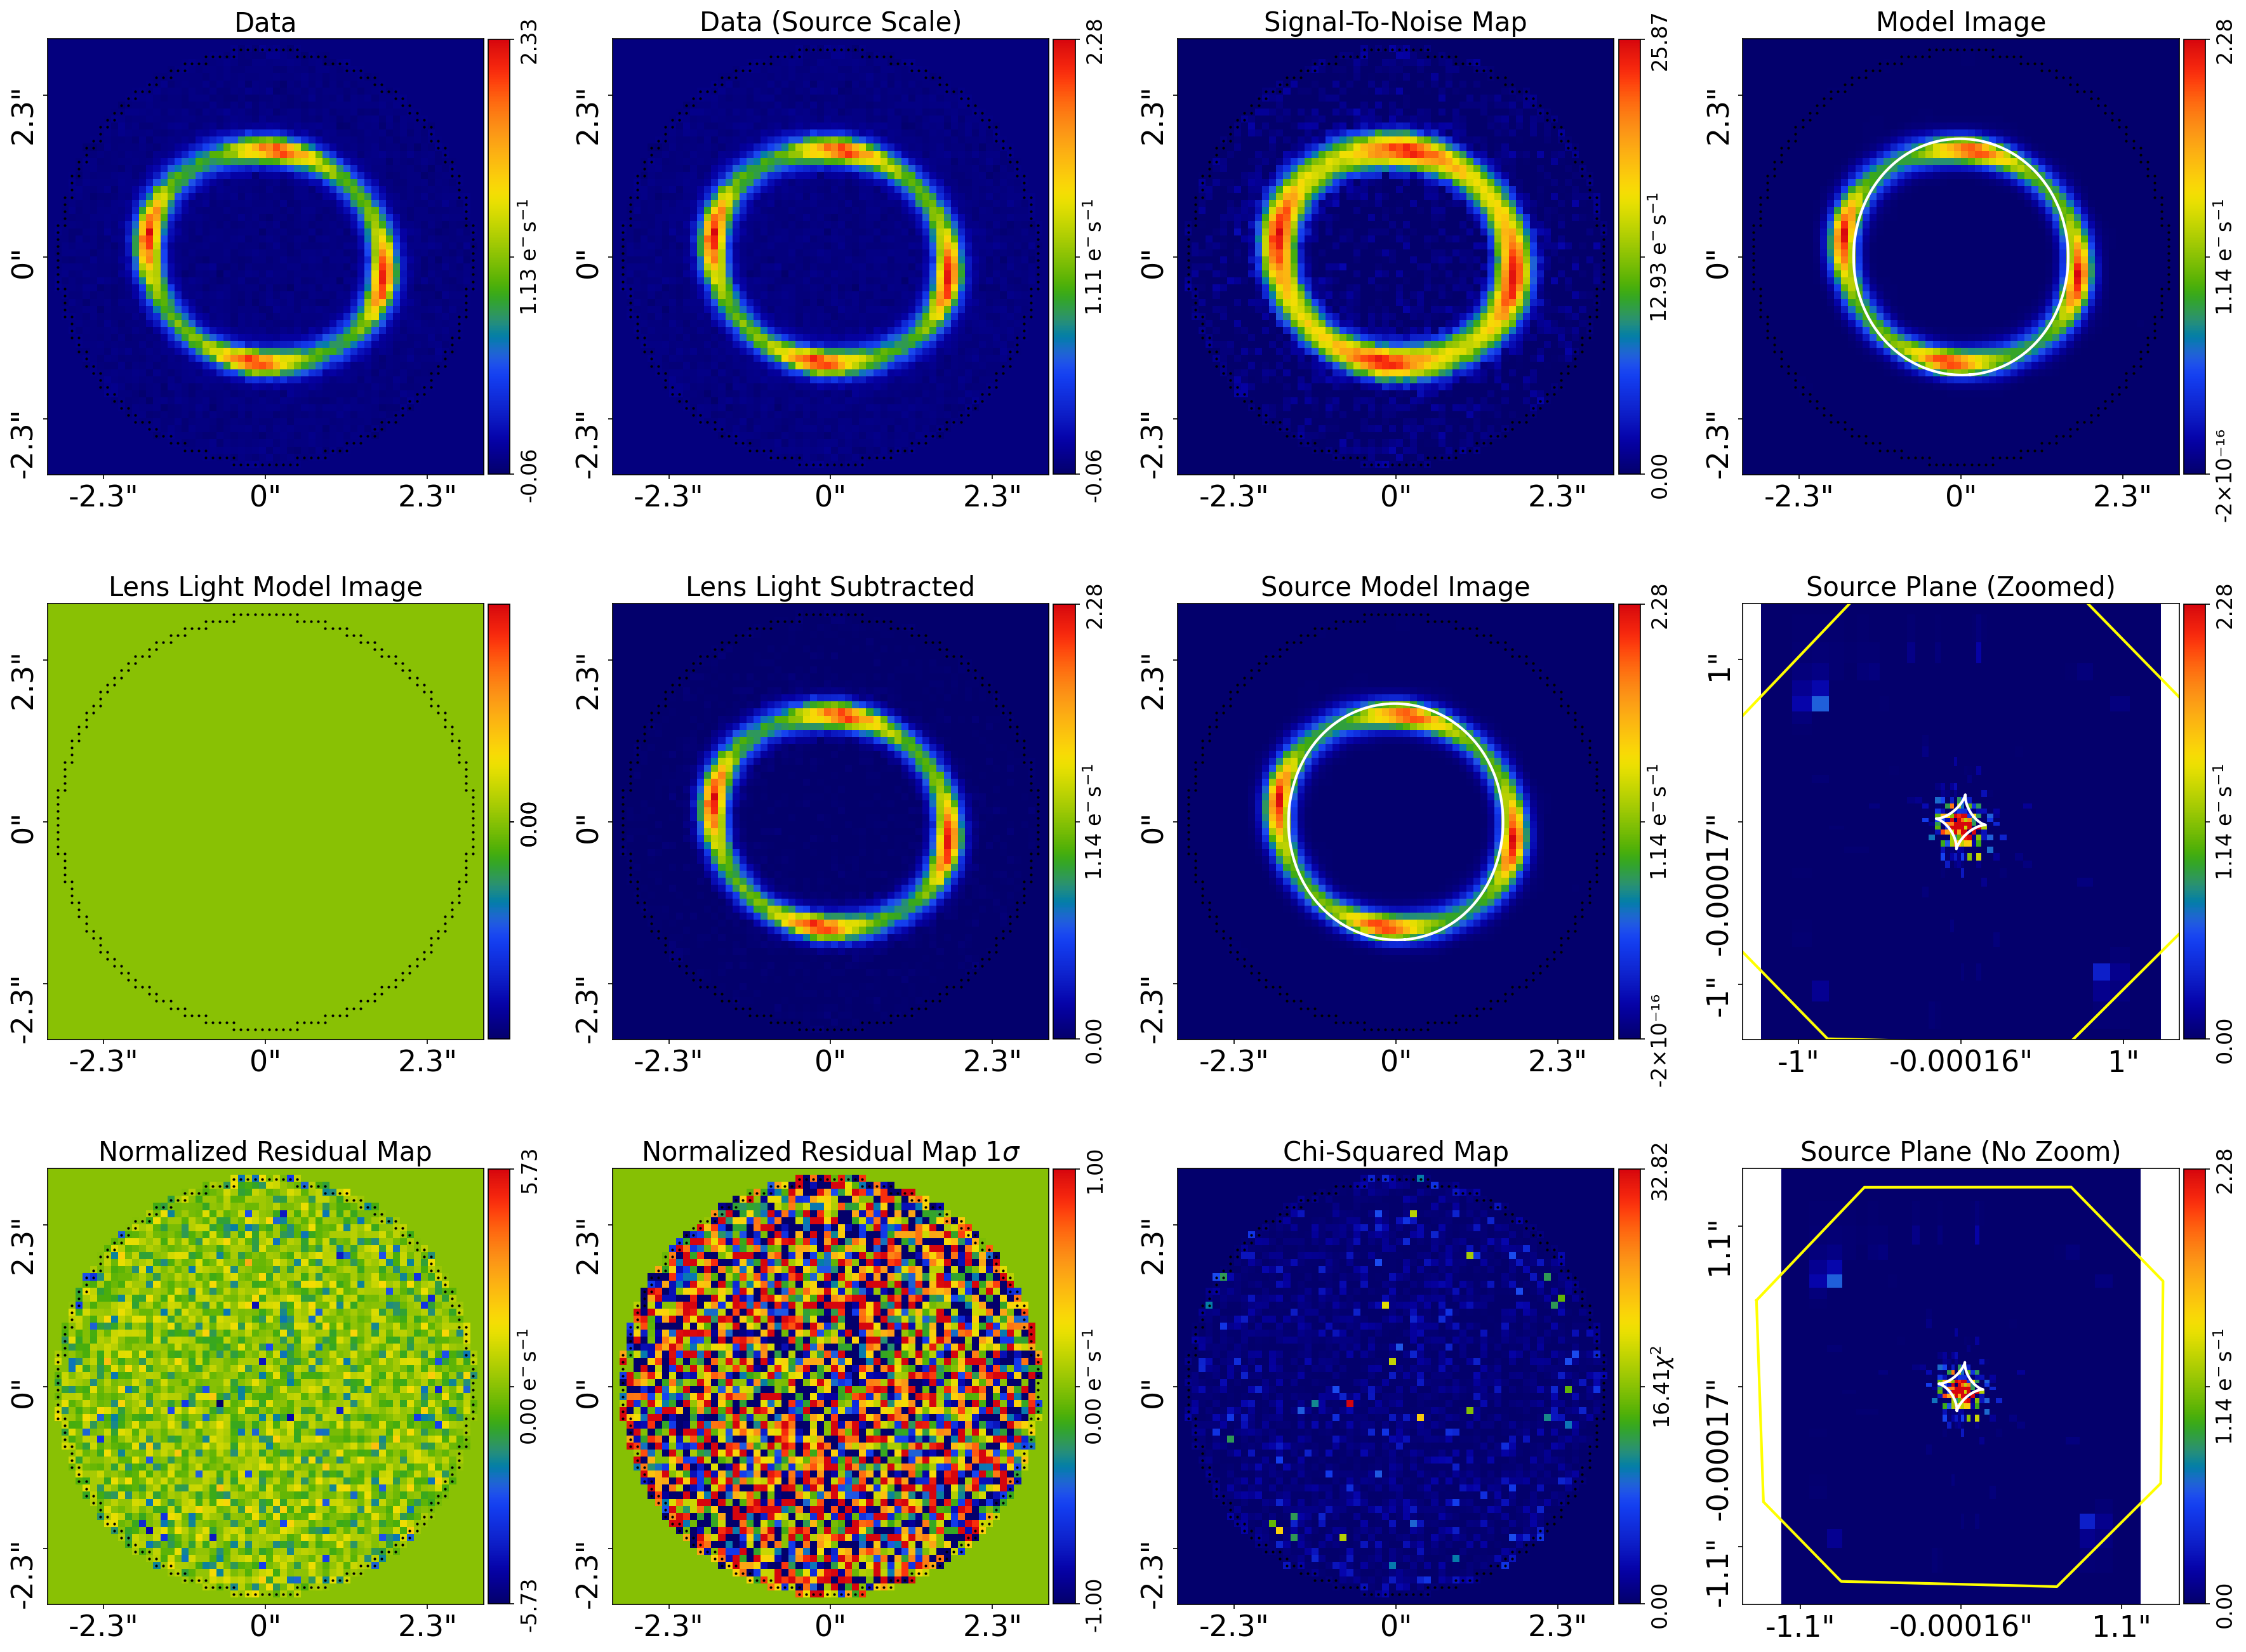

**Posterior corner plot:**

**`model_results.txt`** (first 40 lines):

```
Bayesian Evidence                                                               6584.82033077
Maximum Log Likelihood                                                          6625.32600733

model                                                                           Collection (N=8)
    galaxies                                                                    Collection (N=8)
        lens                                                                    Galaxy (N=7)
            mass                                                                Isothermal (N=5)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=1)
            pixelization                                                        Pixelization (N=1)
                mesh                                                            RectangularAdaptDensity (N=0)
                regularization                                                  Constant (N=1)

Maximum Log Likelihood Model:

galaxies
    lens
        mass
            centre
                centre_0                                                        -0.001
                centre_1                                                        -0.001
            ell_comps
                ell_comps_0                                                     -0.052
                ell_comps_1                                                     -0.000
            einstein_radius                                                     1.601
        shear
            gamma_1                                                             0.048
            gamma_2                                                             -0.049
    source
        pixelization
            regularization
                coefficient                                                     0.001


Summary (3.0 sigma limits):

galaxies
    lens
        mass
            centre
```

In [1]:
import json
from pathlib import Path
from IPython.display import Image, IFrame, display, Markdown

RESULTS_ROOT = Path("../Modules/05_Pixelized_Source_Reconstructions/results")  # relative to this notebook's directory

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"no results directory for stage {stage_name!r}")
        return

    summary = json.loads((stage_dir / "summary.json").read_text())
    display(Markdown(
        f"### `{stage_name}`\n"
        f"- max log-likelihood: **{summary.get('max_log_likelihood'):.2f}**\n"
        f"- log evidence: **{summary.get('log_evidence'):.2f}**\n"
        f"- χ²/N = **{summary.get('chi_squared_per_pixel'):.3f}** "
        f"({summary.get('chi_squared_total'):.0f} / {summary.get('n_unmasked_pixels')} unmasked px)\n"
        f"- max |normalized residual| = **{summary.get('max_abs_normalized_residual'):.2f} σ**"
    ))

    fit_png = stage_dir / "fit_subplot.png"
    if fit_png.exists():
        display(Markdown("**Fit subplot** (data, model, residuals, normalized residuals):"))
        display(Image(filename=str(fit_png)))

    corner_pdf = stage_dir / "corner.pdf"
    if corner_pdf.exists():
        display(Markdown("**Posterior corner plot:**"))
        display(IFrame(src=str(corner_pdf), width=720, height=720))

    mr = stage_dir / "model_results.txt"
    if mr.exists():
        preview = "\n".join(mr.read_text().splitlines()[:40])
        display(Markdown(f"**`model_results.txt`** (first 40 lines):\n\n```\n{preview}\n```"))

show_result("search2_pixelized_source")
